In [29]:
import matplotlib.pyplot as plt
import numpy as np 
import yfinance as yf
import pandas as pd

In [43]:
tickers = ["PSRW.L", "SPLV", "XDEM.L", "IWMO.L", "XDEV.L", "QQQ"]
#Current interest rate (annual)
int_rate = 0.035
log_rate = 1/12 * np.log(1+int_rate)

In [ ]:

data = yf.download(tickers, period="10y", interval="1mo")

[*********************100%***********************]  6 of 6 completed


In [31]:
data.head()
yftickers = list(data.columns.levels[1])

In [32]:

close = data["Close"].to_numpy()
print(close.shape)
#We only need to work with close prices as using both open and close will result in gap ups and gap downs 
#And then using log returns we have 
log_close = np.log(close)
log_returns = log_close[1:] - log_close[:-1]

(120, 6)


In [42]:
log_returns == np.log(close[1:]/close[:-1])

array([[False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, Fa

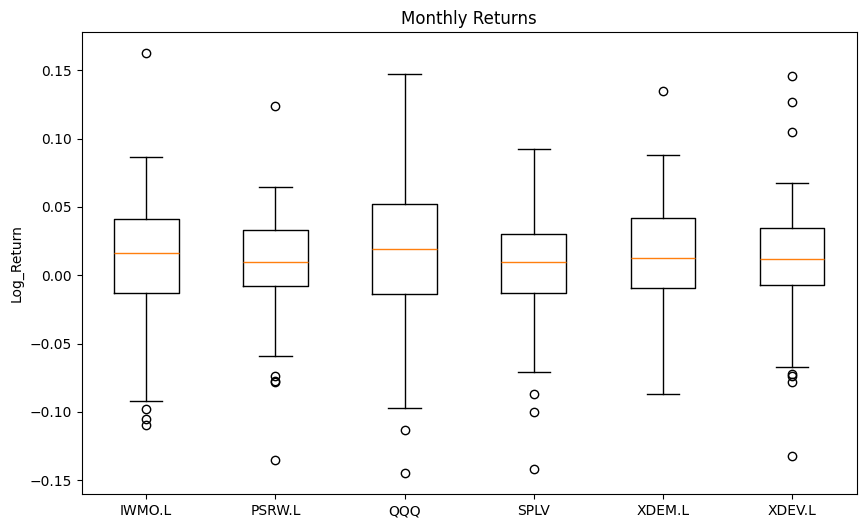

In [33]:
plt.figure(figsize=(10, 6))
plt.boxplot(log_returns, tick_labels=yftickers)

plt.title("Monthly Returns")
plt.ylabel("Log_Return")
plt.show()

In [ ]:
#Now we are interested in measuring correlation between these assets
#or we can just find the covariance matrix as that will be enough
mean_returns = np.mean(log_returns, axis=0)
cent_returns = log_returns - mean_returns
cov_matrix = (cent_returns.T@cent_returns)/(log_returns.shape[0]-1)
volatility = [np.sqrt(cov_matrix[i,i]) for i in range(len(mean_returns))]

In [35]:
for row in cov_matrix:
    print(" ".join(f"{x:8.6f}" for x in row))

0.002011 0.001009 0.002049 0.001093 0.001524 0.001032
0.001009 0.001252 0.001156 0.000785 0.000987 0.001262
0.002049 0.001156 0.002985 0.001096 0.001537 0.001155
0.001093 0.000785 0.001096 0.001372 0.000699 0.000687
0.001524 0.000987 0.001537 0.000699 0.001587 0.000985
0.001032 0.001262 0.001155 0.000687 0.000985 0.001495


Text(0.5, 1.0, 'Risk Reward Tradeoff')

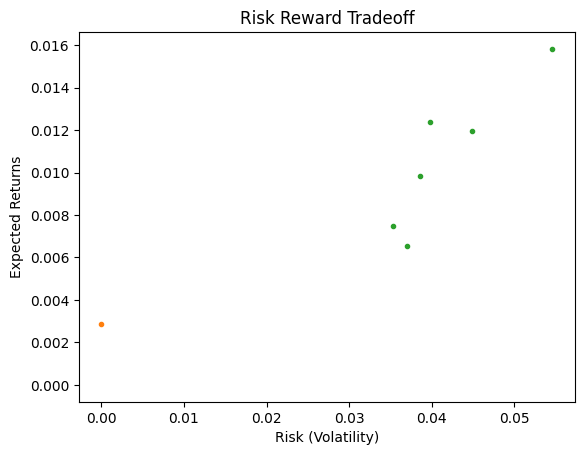

In [49]:
plt.plot(0, 0)
plt.plot(0, log_rate, ".")
plt.plot([np.sqrt(cov_matrix[i,i]) for i in range(len(mean_returns))], mean_returns, ".")
plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Returns")
plt.title("Risk Reward Tradeoff")


In [90]:
#Now we need to plot the Efficient Frontier 
from scipy.optimize import minimize
#We want the minimum variance portfolio which is defined by: 
min_func=lambda x: x@cov_matrix@x
#For the constraints we need the xi's to sum to 1 
#We also need to specify what the expectation of the portfolio should be and we will ultimately be finding the
#min variance portfolio for that specified expectation. 

#Lastly we need to bound our x vector to be non-negative as this portfolio will be used in an ISA. 
bnds = [(0,1)]*len(yftickers)
x0 = np.ones(len(yftickers))/len(yftickers)
Optimal_portfolios = dict()
Ep_range = np.linspace(min(mean_returns), max(mean_returns), 101)
for Ep in Ep_range:
    x_vec = minimize(
        min_func, x0, constraints=({"type": "eq", "fun": lambda x: np.sum(x) -1}
                ,{"type": "eq", "fun": lambda x: np.dot(mean_returns, x) - Ep}), bounds=bnds
    )
    #x is the attribute which contains the solution vector for the optimisation object
    Optimal_portfolios[Ep] = x_vec.x


In [105]:
np.dot(x_vec.x, np.dot(x_vec.x, cov_matrix))

np.float64(0.0029852139695190887)

Text(0.5, 1.0, 'Risk Reward Tradeoff')

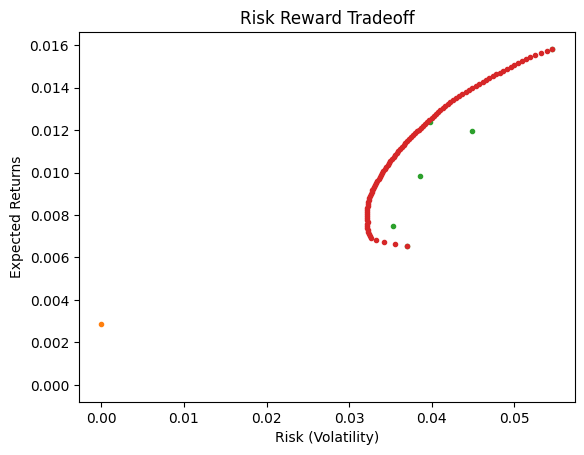

In [106]:
volatility_list = []
for Ep in Ep_range:
    x = Optimal_portfolios[Ep]
    volatility_list.append(np.sqrt(x @ cov_matrix @ x))



plt.plot(0, 0)
plt.plot(0, log_rate, ".")
plt.plot([np.sqrt(cov_matrix[i,i]) for i in range(len(mean_returns))], mean_returns, ".")
plt.plot(volatility_list, Ep_range, ".")
plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Returns")
plt.title("Risk Reward Tradeoff")


In [ ]:
#Now we need to find the capital market line, 
#this is the point where the risk free rate (for me im using the savings rate)
#is tangential to the Efficient Frontier. 
